In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE



In [22]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)


In [24]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [25]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Convert categorical columns using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [26]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)


In [14]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8133427963094393
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.52      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



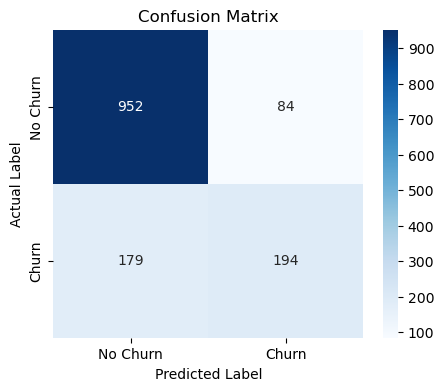

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:


# Get feature importance
importances = model.feature_importances_
feature_names = X.columns

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select Top 3
top3 = feat_df.head(3)["Feature"].values
print("Top 3 Features:", top3)

Top 3 Features: ['tenure' 'TotalCharges' 'MonthlyCharges']


In [ ]:



# Get feature importance
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top3 = feat_df.head(3)["Feature"].values
print("Top 3 Features:", top3)

Top 3 Features: ['tenure' 'TotalCharges' 'MonthlyCharges']


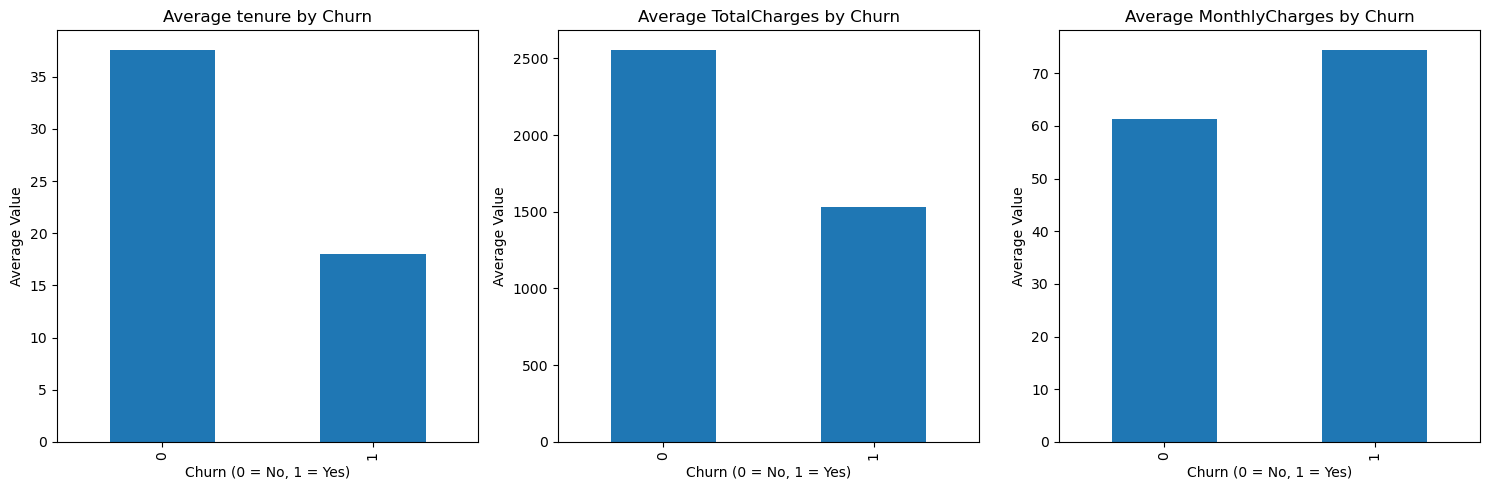

In [32]:
plt.figure(figsize=(15,5))

for i, col in enumerate(top3):
    plt.subplot(1,3,i+1)
    
    # Average value grouped by churn
    df.groupby("Churn")[col].mean().plot(kind="bar")
    
    plt.title(f"Average {col} by Churn")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel("Average Value")

plt.tight_layout()
plt.show()


Top 10 Important Features:

                           Feature  Importance
1                           tenure    0.184601
3                     TotalCharges    0.168477
2                   MonthlyCharges    0.122737
25               Contract_Two year    0.065822
10     InternetService_Fiber optic    0.064124
28  PaymentMethod_Electronic check    0.051809
13              OnlineSecurity_Yes    0.036441
24               Contract_One year    0.033403
19                 TechSupport_Yes    0.023343
26            PaperlessBilling_Yes    0.021831


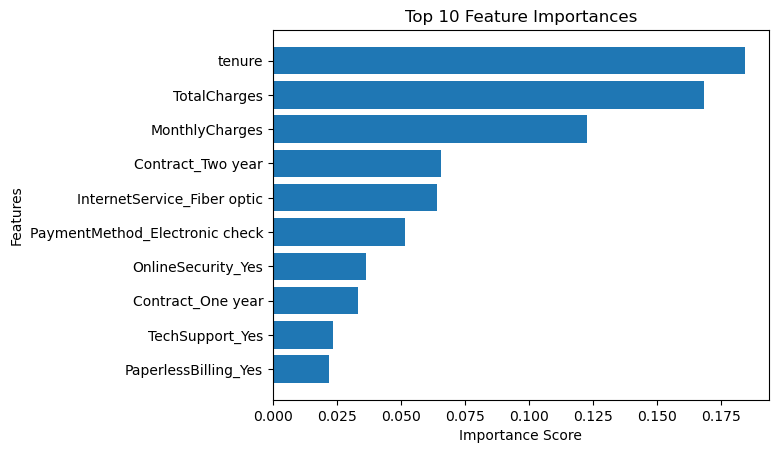

In [34]:
# ------------------------------------------------------------
# 8. Feature Importance
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Get feature importance values
importances = model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

# Show top 10 important features
print("\nTop 10 Important Features:\n")
print(feature_importance_df.head(10))

# Plot Top 10
top10 = feature_importance_df.head(10)

plt.figure()
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()